# 01 - Data Understanding

## Project

Early Prediction of Student Academic Performance Using Machine Learning

## Objective

This notebook performs the initial data understanding stage of the
NIA mini project. It examines the structure, dimensions, variables,
data types, missing values, duplicate records, unique values, and
statistical characteristics of the Student Performance dataset.

## Research Question

Can demographic, academic, behavioural, and social factors be used
to predict students' final academic performance using machine
learning?

## Dataset

Student Performance dataset obtained from the UCI Machine Learning
Repository.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

PROJECT_ROOT = Path.cwd()

FEATURES_PATH = PROJECT_ROOT / "data" / "raw" / "student_performance_features.csv"
TARGETS_PATH = PROJECT_ROOT / "data" / "raw" / "student_performance_targets.csv"

print("Project root:", PROJECT_ROOT)
print("Features path:", FEATURES_PATH)
print("Targets path:", TARGETS_PATH)

features = pd.read_csv(FEATURES_PATH)
targets = pd.read_csv(TARGETS_PATH)

df = pd.concat([features, targets], axis=1)

print("\nDataset loaded successfully.")
print(f"Shape: {df.shape}")

Project root: /home/gmhc26/Documents/student-performance-ml
Features path: /home/gmhc26/Documents/student-performance-ml/data/raw/student_performance_features.csv
Targets path: /home/gmhc26/Documents/student-performance-ml/data/raw/student_performance_targets.csv

Dataset loaded successfully.
Shape: (649, 33)


In [2]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [3]:
df.tail()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
644,MS,F,19,R,GT3,T,2,3,services,other,...,5,4,2,1,2,5,4,10,11,10
645,MS,F,18,U,LE3,T,3,1,teacher,services,...,4,3,4,1,1,1,4,15,15,16
646,MS,F,18,U,GT3,T,1,1,other,other,...,1,1,1,1,1,5,6,11,12,9
647,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,6,10,10,10
648,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,4,10,11,11


In [4]:
df.sample(5, random_state=42)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
636,MS,M,18,U,GT3,T,4,4,teacher,teacher,...,3,2,4,1,4,2,4,17,18,19
220,GP,F,16,U,GT3,A,3,1,services,other,...,2,3,3,2,2,4,2,11,11,12
594,MS,F,18,U,GT3,T,4,4,teacher,teacher,...,4,3,5,1,2,1,0,18,18,18
429,MS,M,16,R,LE3,A,4,4,at_home,other,...,5,3,2,1,3,2,5,10,11,11
72,GP,F,15,R,GT3,T,1,1,other,other,...,3,3,4,2,4,5,2,13,11,11


In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 649
Columns: 33


In [6]:
df.columns.tolist()

['school',
 'sex',
 'age',
 'address',
 'famsize',
 'Pstatus',
 'Medu',
 'Fedu',
 'Mjob',
 'Fjob',
 'reason',
 'guardian',
 'traveltime',
 'studytime',
 'failures',
 'schoolsup',
 'famsup',
 'paid',
 'activities',
 'nursery',
 'higher',
 'internet',
 'romantic',
 'famrel',
 'freetime',
 'goout',
 'Dalc',
 'Walc',
 'health',
 'absences',
 'G1',
 'G2',
 'G3']

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      649 non-null    str  
 1   sex         649 non-null    str  
 2   age         649 non-null    int64
 3   address     649 non-null    str  
 4   famsize     649 non-null    str  
 5   Pstatus     649 non-null    str  
 6   Medu        649 non-null    int64
 7   Fedu        649 non-null    int64
 8   Mjob        649 non-null    str  
 9   Fjob        649 non-null    str  
 10  reason      649 non-null    str  
 11  guardian    649 non-null    str  
 12  traveltime  649 non-null    int64
 13  studytime   649 non-null    int64
 14  failures    649 non-null    int64
 15  schoolsup   649 non-null    str  
 16  famsup      649 non-null    str  
 17  paid        649 non-null    str  
 18  activities  649 non-null    str  
 19  nursery     649 non-null    str  
 20  higher      649 non-null    str  
 21  inte

In [8]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

In [9]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [10]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [11]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


In [12]:
df.describe(include="str")

,school,sex,address,famsize,Pstatus,Mjob,Fjob,reason,guardian,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic
count,649,649,649,649,649,649,649,649,649,649,649,649,649,649,649,649,649
unique,2,2,2,2,2,5,5,4,3,2,2,2,2,2,2,2,2
top,GP,F,U,GT3,T,other,other,course,mother,no,yes,no,no,yes,yes,yes,no
freq,423,383,452,457,569,258,367,285,455,581,398,610,334,521,580,498,410


# Data Exploration

The data exploration stage is conducted to understand the
distribution of the target variable, examine relationships between
student characteristics and academic performance, identify potential
outliers, and generate insights that will guide the preprocessing and
machine learning stages.

### Import Visualization Libraries

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

print("Visualization libraries loaded successfully.")

Visualization libraries loaded successfully.


### G3 Distribution

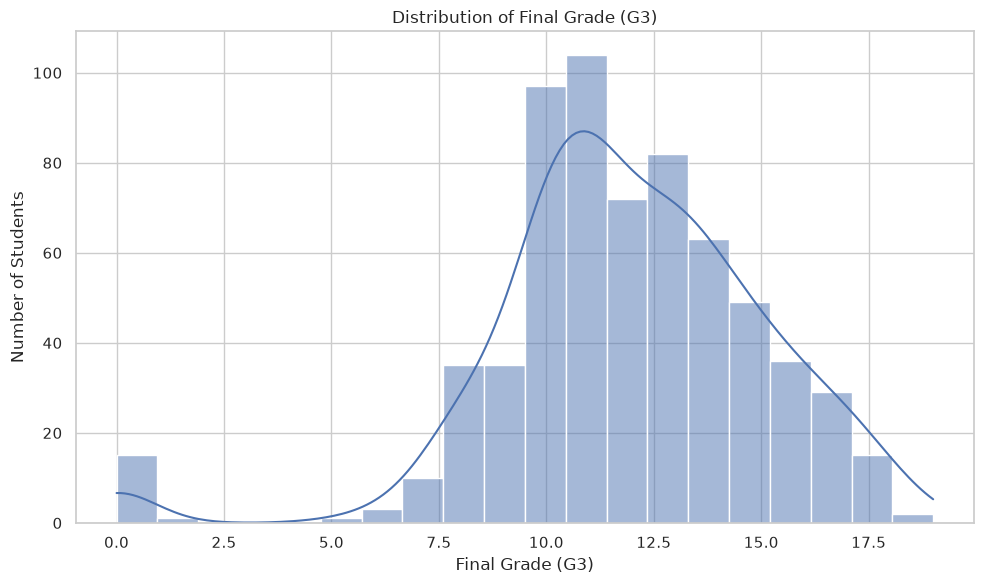

In [14]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="G3",
    bins=20,
    kde=True
)

plt.title("Distribution of Final Grade (G3)")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

### G1, G2 and G3 Comparison

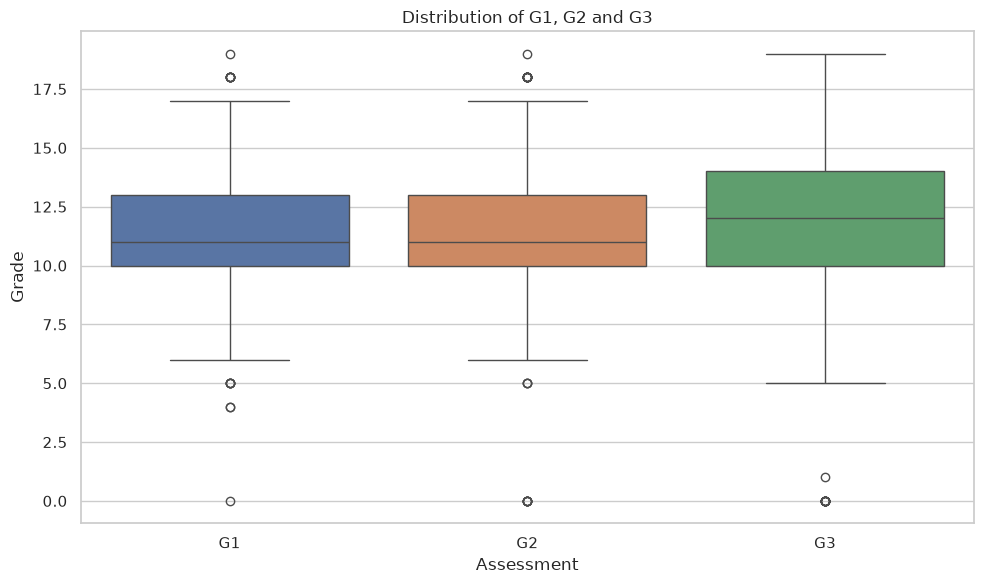

In [15]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df[["G1", "G2", "G3"]]
)

plt.title("Distribution of G1, G2 and G3")
plt.xlabel("Assessment")
plt.ylabel("Grade")

plt.tight_layout()
plt.show()

### Grade Frequency

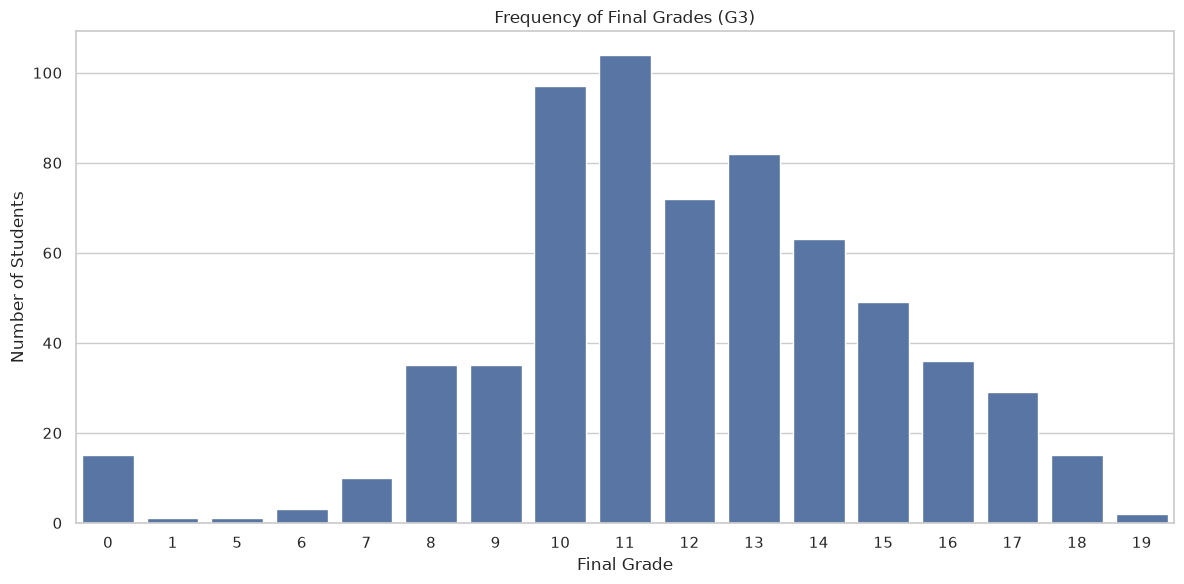

In [16]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="G3"
)

plt.title("Frequency of Final Grades (G3)")
plt.xlabel("Final Grade")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

### Age Distribution

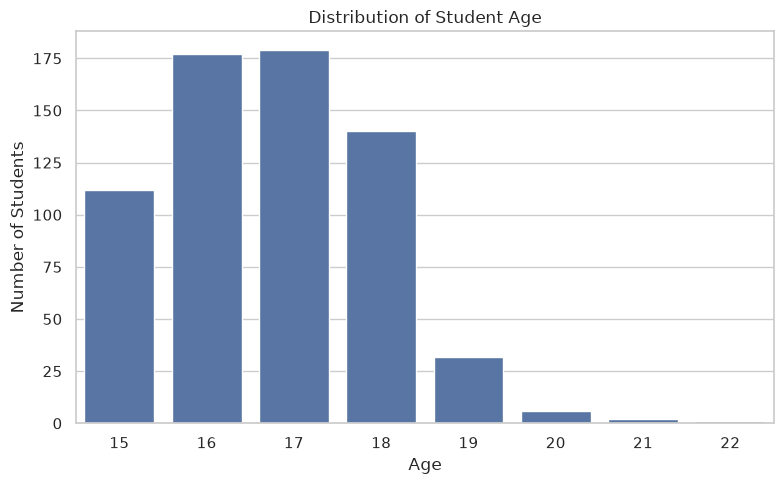

In [17]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="age"
)

plt.title("Distribution of Student Age")
plt.xlabel("Age")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

### Study Time vs Final Grade

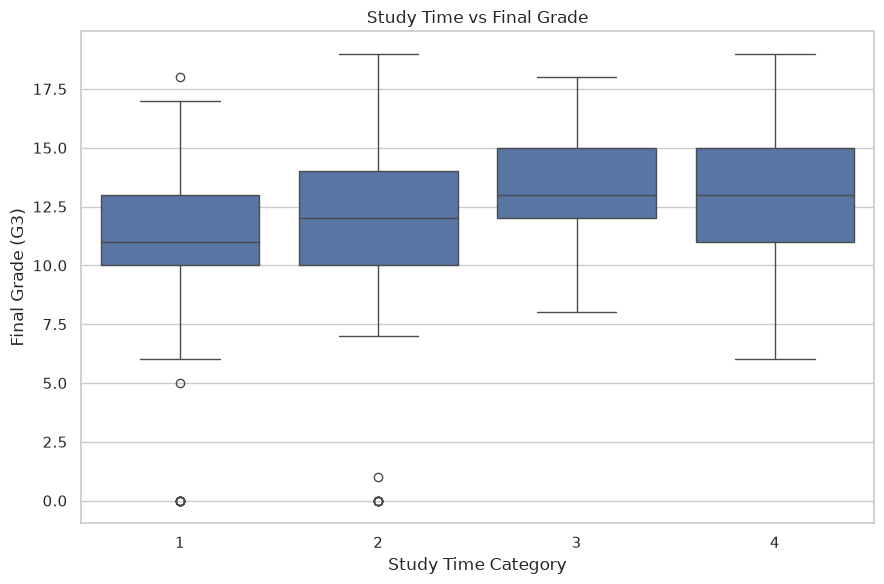

In [18]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="studytime",
    y="G3"
)

plt.title("Study Time vs Final Grade")
plt.xlabel("Study Time Category")
plt.ylabel("Final Grade (G3)")

plt.tight_layout()
plt.show()

### Failures vs Final Grade

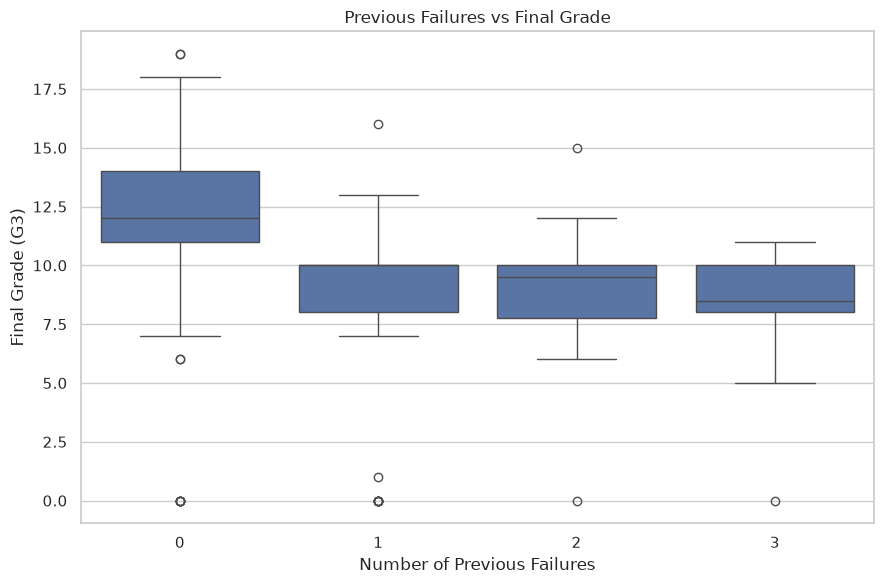

In [19]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="failures",
    y="G3"
)

plt.title("Previous Failures vs Final Grade")
plt.xlabel("Number of Previous Failures")
plt.ylabel("Final Grade (G3)")

plt.tight_layout()
plt.show()

### Absences vs Final Grade

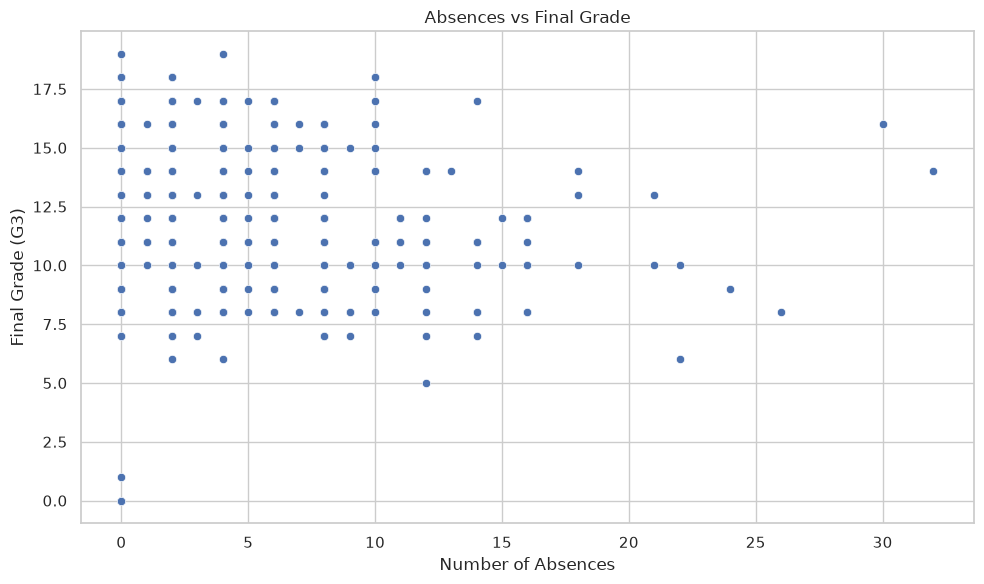

In [20]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="absences",
    y="G3"
)

plt.title("Absences vs Final Grade")
plt.xlabel("Number of Absences")
plt.ylabel("Final Grade (G3)")

plt.tight_layout()
plt.show()

### Correlation Matrix

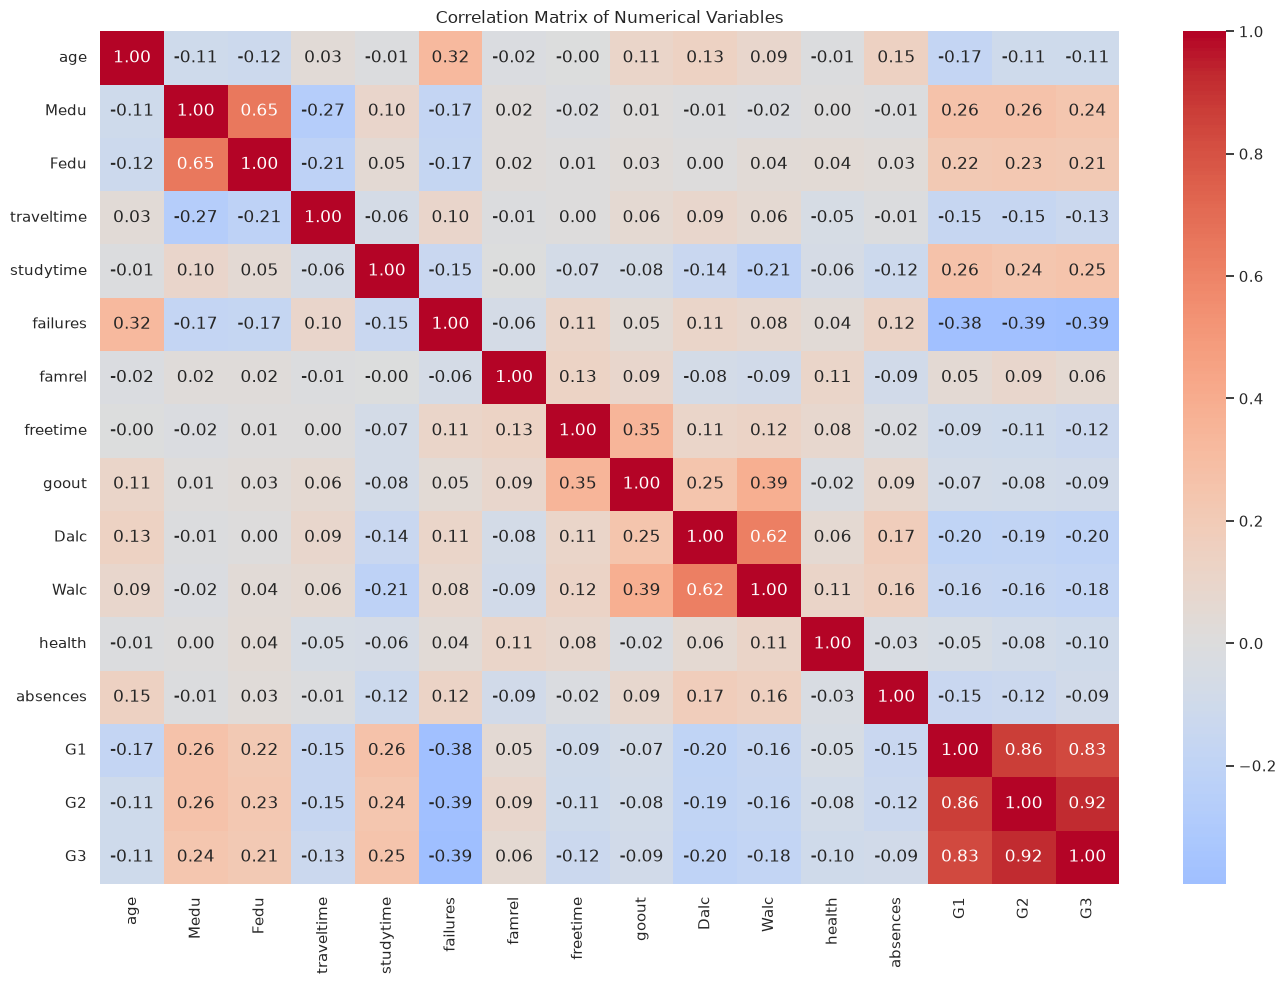

In [21]:
numeric_df = df.select_dtypes(include="number")

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Variables")

plt.tight_layout()
plt.show()

### Correlation With G3

In [22]:
g3_correlations = (
    correlation_matrix["G3"]
    .drop("G3")
    .sort_values(key=abs, ascending=False)
)

g3_correlations

G2            0.918548
G1            0.826387
failures     -0.393316
studytime     0.249789
Medu          0.240151
Fedu          0.211800
Dalc         -0.204719
Walc         -0.176619
traveltime   -0.127173
freetime     -0.122705
age          -0.106505
health       -0.098851
absences     -0.091379
goout        -0.087641
famrel        0.063361
Name: G3, dtype: float64

### Outlier Investigation

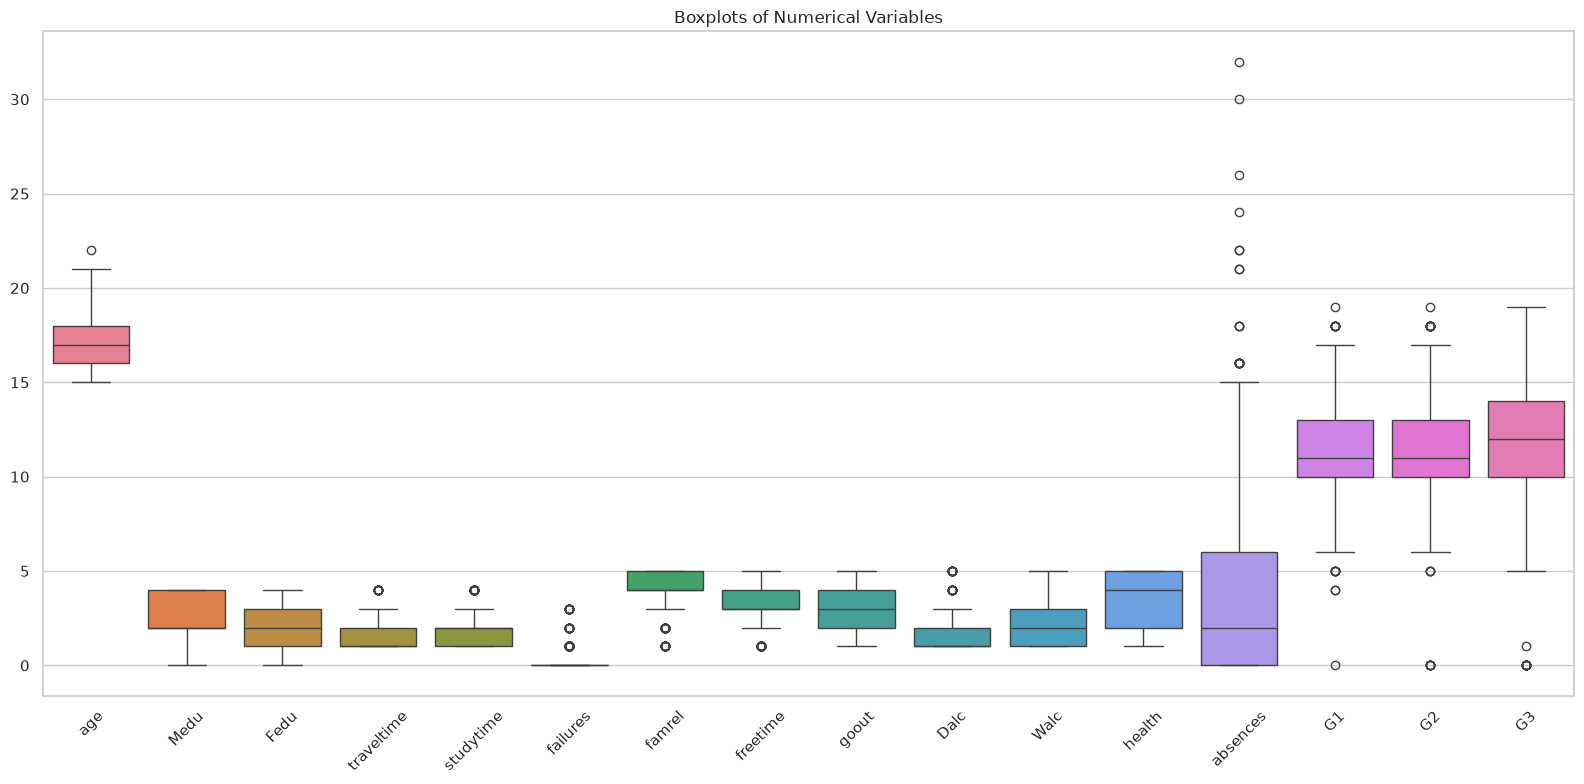

In [23]:
numerical_features = [
    "age",
    "Medu",
    "Fedu",
    "traveltime",
    "studytime",
    "failures",
    "famrel",
    "freetime",
    "goout",
    "Dalc",
    "Walc",
    "health",
    "absences",
    "G1",
    "G2",
    "G3"
]

plt.figure(figsize=(16, 8))

sns.boxplot(
    data=df[numerical_features]
)

plt.title("Boxplots of Numerical Variables")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Outlier Analysis Using the IQR Method

Potential outliers in numerical variables are identified using the
Interquartile Range (IQR) method. An observation is considered a
potential outlier when it falls below Q1 - 1.5 × IQR or above
Q3 + 1.5 × IQR.

Potential outliers are not automatically removed because extreme
values may represent legitimate student observations rather than
data-entry errors.

In [24]:
outlier_summary = []

for column in numerical_features:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ).sum()

    outlier_percentage = (outlier_count / len(df)) * 100

    outlier_summary.append({
        "Variable": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outlier_count,
        "Outlier Percentage": outlier_percentage
    })

outlier_df = pd.DataFrame(outlier_summary)

outlier_df.sort_values(
    by="Outlier Count",
    ascending=False
)

,Variable,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
5,failures,0.0,0.0,0.0,0.0,0.0,100,15.408320
6,famrel,4.0,5.0,1.0,2.5,6.5,51,7.858243
7,freetime,3.0,4.0,1.0,1.5,5.5,45,6.933744
4,studytime,1.0,2.0,1.0,-0.5,3.5,35,5.392912
9,Dalc,1.0,2.0,1.0,-0.5,3.5,34,5.238829
14,G2,10.0,13.0,3.0,5.5,17.5,25,3.852080
12,absences,0.0,6.0,6.0,-9.0,15.0,21,3.235747
3,traveltime,1.0,2.0,1.0,-0.5,3.5,16,2.465331
15,G3,10.0,14.0,4.0,4.0,20.0,16,2.465331
13,G1,10.0,13.0,3.0,5.5,17.5,16,2.465331


### Display Only Variables With Potential Outliers

In [25]:
outlier_df[outlier_df["Outlier Count"] > 0]

,Variable,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,age,16.0,18.0,2.0,13.0,21.0,1,0.154083
3,traveltime,1.0,2.0,1.0,-0.5,3.5,16,2.465331
4,studytime,1.0,2.0,1.0,-0.5,3.5,35,5.392912
5,failures,0.0,0.0,0.0,0.0,0.0,100,15.408320
6,famrel,4.0,5.0,1.0,2.5,6.5,51,7.858243
7,freetime,3.0,4.0,1.0,1.5,5.5,45,6.933744
9,Dalc,1.0,2.0,1.0,-0.5,3.5,34,5.238829
12,absences,0.0,6.0,6.0,-9.0,15.0,21,3.235747
13,G1,10.0,13.0,3.0,5.5,17.5,16,2.465331
14,G2,10.0,13.0,3.0,5.5,17.5,25,3.852080


### More Useful G3 Analysis

In [26]:
failure_summary = (
    df.groupby("failures")["G3"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)

failure_summary

,count,mean,median,std,min,max
failures,,,,,,
0,549,12.51,12.0,2.83,0,19
1,70,8.64,10.0,3.44,0,16
2,16,8.81,9.5,3.21,0,15
3,14,8.07,8.5,2.79,0,11


In [27]:
studytime_summary = (
    df.groupby("studytime")["G3"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)

studytime_summary

,count,mean,median,std,min,max
studytime,,,,,,
1,212,10.84,11.0,3.22,0,18
2,305,12.09,12.0,3.24,0,19
3,97,13.23,13.0,2.50,8,18
4,35,13.06,13.0,3.04,6,19


In [28]:
absence_summary = (
    df.groupby("absences")["G3"]
    .agg(["count", "mean", "median"])
    .round(2)
)

absence_summary.head(20)

,count,mean,median
absences,,,
0,244,12.04,13.0
1,12,12.42,12.5
2,110,12.19,12.0
3,7,10.43,10.0
4,93,12.01,11.0
5,12,11.75,11.0
6,49,12.12,12.0
7,3,13.00,15.0
8,42,11.62,11.0


# Early Prediction Feature Selection

The primary research experiment focuses on early prediction of final
academic performance. Therefore, G1 and G2 are excluded from the
predictor variables because they represent earlier academic grades
and have very strong relationships with G3.

The remaining demographic, family, social, behavioural, and
school-related variables are used as candidate predictors.

In [29]:
early_prediction_features = df.drop(
    columns=["G1", "G2", "G3"]
)

early_prediction_target = df["G3"]

print("Early prediction feature shape:", early_prediction_features.shape)
print("Target shape:", early_prediction_target.shape)

Early prediction feature shape: (649, 30)
Target shape: (649,)


## Interpretation of Outlier Analysis

The IQR method identified potential statistical outliers in several
variables. However, the dataset contains multiple ordinal and bounded
variables such as failures, studytime, famrel, freetime, Dalc, and
traveltime.

For these variables, values outside the IQR boundaries do not
necessarily represent incorrect observations. They may represent
legitimate categories with lower frequencies.

Therefore, statistical outlier detection is used as an exploratory
diagnostic rather than an automatic removal rule.

The observations will be retained unless an actual data
inconsistency or invalid value is identified.

### Add Valid-Range Checks

In [33]:
expected_ranges = {
    "age": (15, 22),
    "Medu": (0, 4),
    "Fedu": (0, 4),
    "traveltime": (1, 4),
    "studytime": (1, 4),
    "failures": (0, 3),
    "famrel": (1, 5),
    "freetime": (1, 5),
    "goout": (1, 5),
    "Dalc": (1, 5),
    "Walc": (1, 5),
    "health": (1, 5),
    "G1": (0, 19),
    "G2": (0, 19),
    "G3": (0, 19)
}

range_check_results = []

for column, (minimum, maximum) in expected_ranges.items():
    invalid_count = (
        (df[column] < minimum) |
        (df[column] > maximum)
    ).sum()

    range_check_results.append({
        "Variable": column,
        "Expected Minimum": minimum,
        "Expected Maximum": maximum,
        "Invalid Values": invalid_count
    })

range_check_df = pd.DataFrame(range_check_results)

range_check_df

,Variable,Expected Minimum,Expected Maximum,Invalid Values
0,age,15,22,0
1,Medu,0,4,0
2,Fedu,0,4,0
3,traveltime,1,4,0
4,studytime,1,4,0
5,failures,0,3,0
6,famrel,1,5,0
7,freetime,1,5,0
8,goout,1,5,0
9,Dalc,1,5,0


In [34]:
range_check_df[range_check_df["Invalid Values"] > 0]

,Variable,Expected Minimum,Expected Maximum,Invalid Values
